# Fase 3.5 — Estratègia d'Inicialització del COS: scratch / frozen / finetune

**Continuació de:** [`30_comparacio_sense/comparacio_fase30.ipynb`](../30_comparacio_sense/comparacio_fase30.ipynb)

La Fase 3.0 va establir que l'arquitectura COS no supera sistemàticament el MLP al protocol **mans** (diferència ≤3.6 pp). La hipòtesi és que el motiu és que el COS s'usa amb pesos aleatoris (scratch), sense aprofitar cap coneixement previ sobre el joc. Aquesta fase introdueix el **preentrenament supervisat** del cos i compara quatre règims sobre el protocol mans.

**Objectiu:** Determinar si el preentrenament supervisat del cos aporta valor, i quin règim d'inicialització és òptim.

**Disseny experimental:**
- **2 algorismes**: DQN-SB3, PPO-SB3
- **4 règims**: `sense_cos` (MLP pla), `scratch` (COS init aleatori), `frozen` (COS preentrenat congelat), `finetune` (COS preentrenat entrenable)
- **Protocol**: mans (`TrucGymEnvMa`, 24M steps per run)
- Oponent: 10% Random + 90% AgentRegles (sense self-play)
- Avaluació: 100 partides senceres (`TrucGymEnv`) cada 500 000 steps

| Règim | Pesos inicials | `requires_grad` cos | Font |
|:--|:--|:--|:--|
| sense_cos (MLP) | — | — | **F3.0 reutilitzat** |
| scratch | SB3 random init | True | **F3.0 reutilitzat** |
| frozen | `best_pesos_cos_truc.pth` | **False** | nou |
| finetune | `best_pesos_cos_truc.pth` | True | nou |

---

## 1. Context teòric

### 1.1 Arquitectura COS i MLP estàndard

Per als detalls d'arquitectura (`CosMultiInputSB3`, `CombinedExtractor`, observació de 240 dims) i les mètriques d'avaluació, veure la secció 1 del notebook anterior [`comparacio_fase30.ipynb`](../30_comparacio_sense/comparacio_fase30.ipynb).

La Fase 3.0 usava el COS **sempre en mode scratch** (pesos aleatoris). La principal novetat d'aquesta fase és el **preentrenament supervisat** del cos: abans de començar el RL, els pesos de `CosMultiInput` s'inicialitzen via aprenentatge supervisat sobre un dataset d'estats de Truc.

### 1.2 Preentrenament supervisat del cos

El cos es preentrena amb `RL/entrenament/entrenamentEstatTruc/preentrenar_cos.py`. S'instancia un `ModelPreEntrenament` (`CosMultiInput` + tres caps lineals) i s'entrena per predir:

| Cap | Target | Loss |
|:--|:--|:--|
| `cap_envit` | Punts d'envit de la mà (normalitzats /35) | MSE |
| `cap_accions_legals` | Màscara binària d'accions legals (19 bits) | BCE |
| `cap_forces` | Força de cada carta (3 valors, normalitzats) | MSE |

**Loss combinada:** `1.0·envit + 2.0·accions + 2.5·forces`

El dataset (200 000 mostres) es genera amb política pseudo-aleatòria sobre `TrucEnv` real. Split 80/20 train/val, `patience=10`, regeneració cada 20 epochs per evitar sobreajust.

Un cop acabat el preentrenament, **les caps es descarten**. Només es guarden els pesos del cos (`model.cos.state_dict()`) a `best_pesos_cos_truc.pth`. Aquests pesos són els que s'usen per inicialitzar el COS als règims frozen i finetune.

### 1.3 Els quatre règims

| Règim | Hipòtesi | Risc principal |
|:--|:--|:--|
| **sense_cos (MLP)** | Referència absoluta de la Fase 3.0 (mans, MLP pla) | — |
| **scratch** | Línia base arquitectural: COS aleatori, igual que F3.0 | Convergència lenta sense inducció de coneixement |
| **frozen** | El cos preentrenat proporciona representació rica des del primer step; la política s'adapta ràpidament | Sostre rígid si la representació no cobreix tot el que cal |
| **finetune** | Millor dels dos mons: punt de partida bo i cos adaptable | *Catastrophic forgetting* si el gradient RL desplaça el cos prematurament |

---

## 2. El preentrenament supervisat del cos

Abans de poder usar els règims **frozen** i **finetune**, cal disposar de `best_pesos_cos_truc.pth`: els pesos de `CosMultiInput` obtinguts per aprenentatge supervisat. Aquesta secció carrega el log d'entrenament supervisat i mostra la convergència de les tres components de la loss.

El preentrenament **no forma part del bucle RL**. Genera uns pesos inicials que codifiquen coneixement tàctic sobre el Truc (força de cartes, accions legals, punts d'envit) de manera independent de la política. Un cop obtinguts, les caps de supervisió es descarten i només es conserven els pesos del cos.

Log de preentrenament: 15_04_26_a_les_1217
  Èpoques totals: 5
  Val loss final: 0.0269
  Val envit (MSE): 0.0212
  Val accions (BCE): 0.0012
  Val forces (MSE): 0.0013


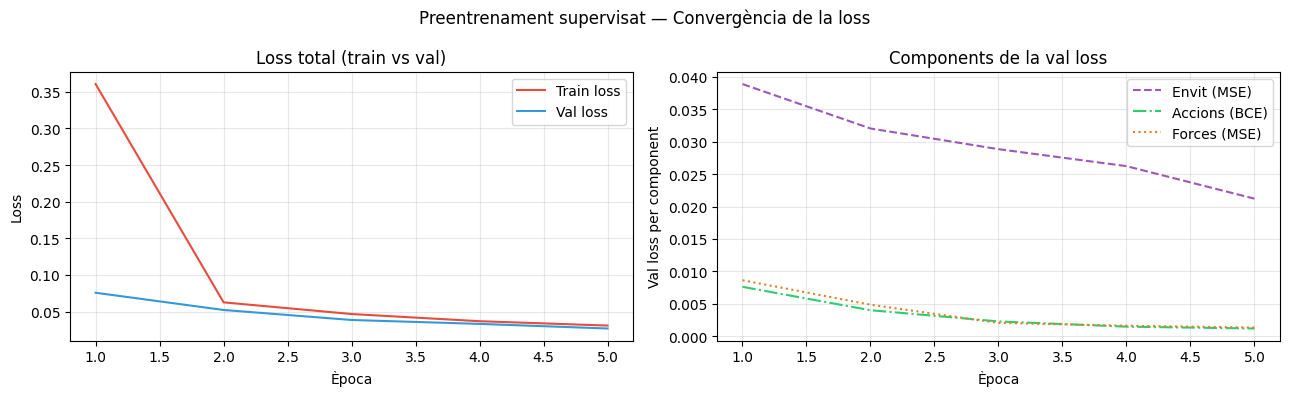

In [1]:
import sys
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Localitzar el registre de preentrenament més recent
_BASE_PRE = Path('../../../..') / 'RL/entrenament/entrenamentEstatTruc/registres'
_logs = sorted(glob.glob(str(_BASE_PRE / '*/logs/preentrenament_log.csv')), key=os.path.getmtime)

if not _logs:
    print('No s\'ha trobat cap log de preentrenament.')
    df_pre = None
else:
    _log_path = Path(_logs[-1])
    df_pre = pd.read_csv(_log_path)
    print(f'Log de preentrenament: {_log_path.parent.parent.name}')
    print(f'  Èpoques totals: {len(df_pre)}')
    print(f'  Val loss final: {df_pre["val_loss"].iloc[-1]:.4f}')
    print(f'  Val envit (MSE): {df_pre["val_env"].iloc[-1]:.4f}')
    print(f'  Val accions (BCE): {df_pre["val_acc"].iloc[-1]:.4f}')
    print(f'  Val forces (MSE): {df_pre["val_forces"].iloc[-1]:.4f}')

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle('Preentrenament supervisat — Convergència de la loss', fontsize=12)

    # Esquerra: train vs val loss total
    ax = axes[0]
    ax.plot(df_pre['epoca'], df_pre['train_loss'], label='Train loss', color='#e74c3c')
    ax.plot(df_pre['epoca'], df_pre['val_loss'],   label='Val loss',   color='#3498db')
    ax.set_xlabel('Època')
    ax.set_ylabel('Loss')
    ax.set_title('Loss total (train vs val)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Dreta: components de la val loss
    ax = axes[1]
    ax.plot(df_pre['epoca'], df_pre['val_env'],    label='Envit (MSE)',    color='#9b59b6', linestyle='--')
    ax.plot(df_pre['epoca'], df_pre['val_acc'],    label='Accions (BCE)',  color='#2ecc71', linestyle='-.')
    ax.plot(df_pre['epoca'], df_pre['val_forces'], label='Forces (MSE)',   color='#e67e22', linestyle=':')
    ax.set_xlabel('Època')
    ax.set_ylabel('Val loss per component')
    ax.set_title('Components de la val loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

---

## 3. Setup

In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

sys.path.insert(0, str(Path('../../utils')))
from nb_utils import (setup_pyplot, suavitzar,
                      trobar_ultima_carpeta as _trobar,
                      step_first_above,
                      COLORS_VARIANTS, LABELS_VARIANTS,
                      LSTYLE_VARIANTS, LWIDTH_VARIANTS,
                      COLORS_TAG, LABELS_TAG)

setup_pyplot()

AGENTS   = ['dqn_sb3', 'ppo_sb3']
VARIANTS = ['scratch', 'frozen', 'finetune']
ALL_REGIMS = ['sense_cos', 'scratch', 'frozen', 'finetune']

COLORS   = COLORS_VARIANTS
LABELS_A = {'dqn_sb3': 'DQN-SB3', 'ppo_sb3': 'PPO-SB3'}
LABELS_V = LABELS_VARIANTS
LSTYLE   = LSTYLE_VARIANTS
LWIDTH   = LWIDTH_VARIANTS

# Sense COS (MLP) — referència de Fase 3.0
COLOR_SANS  = '#2c3e50'
LSTYLE_SANS = '-.'
LWIDTH_SANS = 1.6
LABEL_SANS  = 'Sense COS (MLP)'

BASE = Path('../../../..')

def trobar_ultima_carpeta(patro: str) -> Path | None:
    return _trobar(patro, base=BASE)

def carregar_dades_fase35(carpeta_base: Path) -> dict:
    dades = {a: {} for a in AGENTS}
    for agent in AGENTS:
        for variant in VARIANTS:
            path = carpeta_base / f'{agent}_{variant}' / 'training_log.csv'
            if path.exists():
                dades[agent][variant] = pd.read_csv(path)
    return dades

print('Setup completat.')
print(f'Directori base: {BASE.resolve()}')

Setup completat.
Directori base: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc


---

## 4. Càrrega de dades

In [3]:
carpeta = BASE / 'TFG_Doc/notebooks/3_feature_extractor/resultats'

if not carpeta.exists():
    print('No s\'ha trobat la carpeta de resultats.')
    dades = {a: {} for a in AGENTS}
    ref_sans_cos = {}
else:
    print(f'Carpeta: {carpeta}')
    dades = carregar_dades_fase35(carpeta)
    print()
    for agent in AGENTS:
        for variant in VARIANTS:
            df = dades[agent].get(variant)
            if df is not None:
                print(f'  {LABELS_A[agent]} {LABELS_V[variant]:<35}: '
                      f'{len(df)} aval., max step={df["step"].max()/1e6:.0f}M, '
                      f'millor metric={df["eval_metric"].max():.1f}%')

    # Referència Fase 3.0 — sense COS (mans MLP)
    ref_sans_cos = {}
    for agent in AGENTS:
        path = carpeta / f'{agent}_mans_mlp' / 'training_log.csv'
        if path.exists():
            ref_sans_cos[agent] = pd.read_csv(path)
    if ref_sans_cos:
        print('\nReferència Fase 3.0 — Sense COS (MLP):')
        for agent, df in ref_sans_cos.items():
            print(f'  {LABELS_A[agent]}: millor metric={df["eval_metric"].max():.1f}%')

    resum_path = carpeta / 'resum_fase35.txt'
    if resum_path.exists():
        print('\n' + resum_path.read_text())

Carpeta: ..\..\..\..\TFG_Doc\notebooks\3_feature_extractor\resultats

  DQN-SB3 Scratch (init aleatori)            : 48 aval., max step=24M, millor metric=82.2%
  DQN-SB3 Frozen (pesos preentrenats)        : 48 aval., max step=24M, millor metric=91.2%
  DQN-SB3 Finetune (pesos preentrenats)      : 48 aval., max step=24M, millor metric=88.5%
  PPO-SB3 Scratch (init aleatori)            : 48 aval., max step=24M, millor metric=89.0%
  PPO-SB3 Frozen (pesos preentrenats)        : 48 aval., max step=24M, millor metric=89.5%
  PPO-SB3 Finetune (pesos preentrenats)      : 48 aval., max step=24M, millor metric=88.0%

Referència Fase 3.0 — Sense COS (MLP):
  DQN-SB3: millor metric=85.8%
  PPO-SB3: millor metric=87.2%


---

## 5. Corbes d'aprenentatge

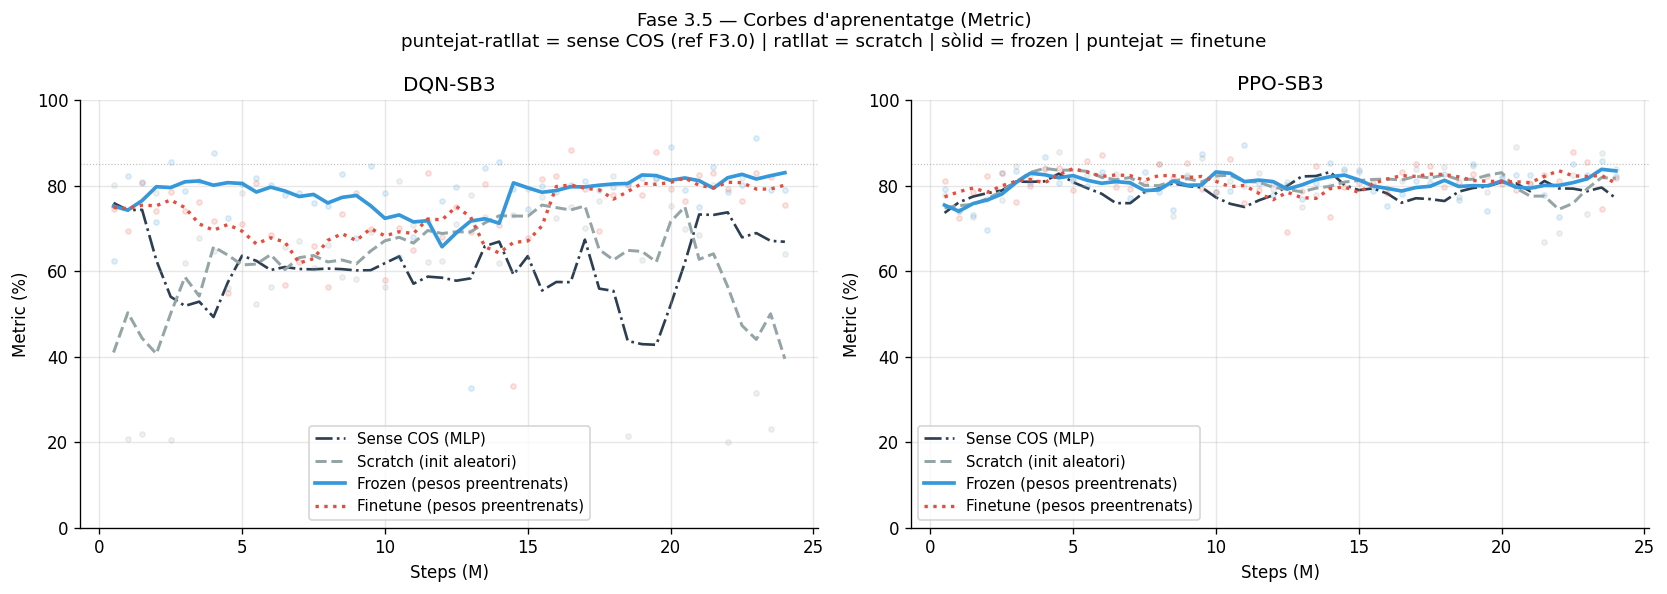

In [4]:
if dades:
    WINDOW = 5
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Fase 3.5 — Corbes d\'aprenentatge (Metric)\n'
                 'puntejat-ratllat = sense COS (ref F3.0) | ratllat = scratch | sòlid = frozen | puntejat = finetune',
                 fontsize=11)

    for ax, agent in zip(axes, AGENTS):
        # Referència Fase 3.0 — sense COS
        df_sans = ref_sans_cos.get(agent)
        if df_sans is not None:
            s = df_sans['step'] / 1e6
            ax.plot(s, suavitzar(df_sans['eval_metric'], WINDOW),
                    color=COLOR_SANS, linestyle=LSTYLE_SANS,
                    linewidth=LWIDTH_SANS, label=LABEL_SANS, zorder=1)

        for variant in VARIANTS:
            df = dades[agent].get(variant)
            if df is None:
                continue
            s   = df['step'] / 1e6
            col = COLORS[variant]
            ax.scatter(s, df['eval_metric'], color=col, alpha=0.15, s=10)
            ax.plot(s, suavitzar(df['eval_metric'], WINDOW),
                    color=col, linestyle=LSTYLE[variant],
                    linewidth=LWIDTH[variant], label=LABELS_V[variant])

        ax.set_title(LABELS_A[agent], fontsize=12)
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel('Metric (%)')
        ax.set_ylim(0, 100)
        ax.axhline(85, color='gray', linestyle=':', linewidth=0.7, alpha=0.5)
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print('Sense dades.')

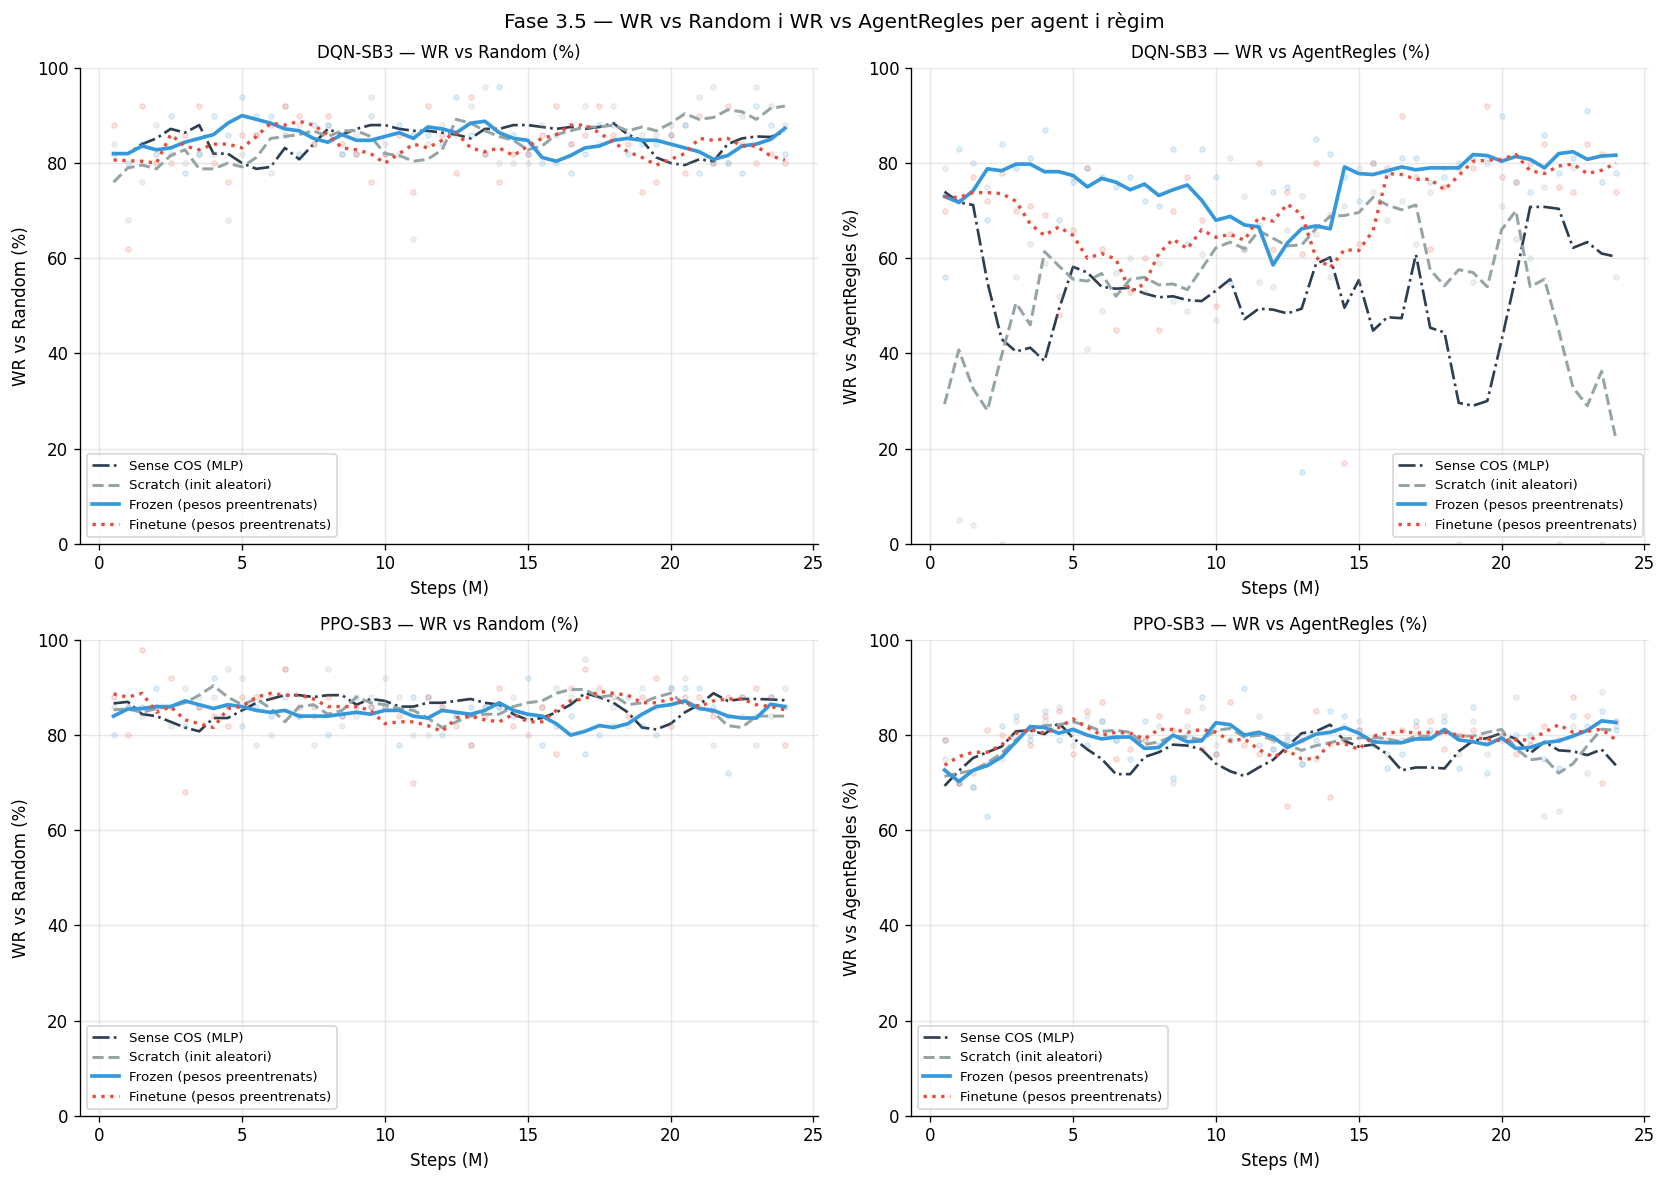

In [5]:
if dades:
    WINDOW = 5
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Fase 3.5 — WR vs Random i WR vs AgentRegles per agent i règim', fontsize=12)

    metriques = ['eval_wr_random', 'eval_wr_regles']
    titols    = ['WR vs Random (%)', 'WR vs AgentRegles (%)']

    for row, agent in enumerate(AGENTS):
        for col_idx, (met, tit) in enumerate(zip(metriques, titols)):
            ax = axes[row][col_idx]

            # Referència sense COS
            df_sans = ref_sans_cos.get(agent)
            if df_sans is not None and met in df_sans.columns:
                s = df_sans['step'] / 1e6
                ax.plot(s, suavitzar(df_sans[met], WINDOW),
                        color=COLOR_SANS, linestyle=LSTYLE_SANS,
                        linewidth=LWIDTH_SANS, label=LABEL_SANS, zorder=1)

            for variant in VARIANTS:
                df = dades[agent].get(variant)
                if df is None:
                    continue
                s   = df['step'] / 1e6
                col = COLORS[variant]
                ax.scatter(s, df[met], color=col, alpha=0.15, s=10)
                ax.plot(s, suavitzar(df[met], WINDOW),
                        color=col, linestyle=LSTYLE[variant],
                        linewidth=LWIDTH[variant], label=LABELS_V[variant])
            ax.set_title(f'{LABELS_A[agent]} — {tit}', fontsize=10)
            ax.set_xlabel('Steps (M)')
            ax.set_ylabel(tit)
            ax.set_ylim(0, 100)
            ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print('Sense dades.')

---

## 6. Velocitat de convergència i taula resum

In [6]:
if dades:
    rows = []

    # Referència sense COS (Fase 3.0)
    for agent in AGENTS:
        df = ref_sans_cos.get(agent)
        if df is None:
            continue
        pic      = df['eval_metric'].max()
        step_pic = df.loc[df['eval_metric'].idxmax(), 'step'] / 1e6
        temps_h  = df['elapsed_s'].max() / 3600 if 'elapsed_s' in df.columns else float('nan')
        rows.append({
            'Agent':           LABELS_A[agent],
            'Règim':           'sense COS (MLP)',
            'Pic metric (%)':  f'{pic:.1f}',
            'Step pic (M)':    f'{step_pic:.1f}',
            '≥85% (1r step)':  step_first_above(df, 85),
            '≥88% (1r step)':  step_first_above(df, 88),
            'Temps (h)':       f'{temps_h:.2f}' if not np.isnan(temps_h) else '—',
        })

    for agent in AGENTS:
        for variant in VARIANTS:
            df = dades[agent].get(variant)
            if df is None:
                continue
            pic      = df['eval_metric'].max()
            step_pic = df.loc[df['eval_metric'].idxmax(), 'step'] / 1e6
            temps_h  = df['elapsed_s'].max() / 3600 if 'elapsed_s' in df.columns else float('nan')
            rows.append({
                'Agent':           LABELS_A[agent],
                'Règim':           variant,
                'Pic metric (%)':  f'{pic:.1f}',
                'Step pic (M)':    f'{step_pic:.1f}',
                '≥85% (1r step)':  step_first_above(df, 85),
                '≥88% (1r step)':  step_first_above(df, 88),
                'Temps (h)':       f'{temps_h:.2f}' if not np.isnan(temps_h) else '—',
            })

    df_resum = pd.DataFrame(rows).set_index(['Agent', 'Règim'])

    def highlight_best(col):
        try:
            vals = col.str.rstrip('%').astype(float)
            is_max = vals == vals.max()
            return ['font-weight: bold; color: green' if v else '' for v in is_max]
        except Exception:
            return ['' for _ in col]

    df_resum.style.apply(highlight_best, subset=['Pic metric (%)'])

---

## 7. Comparació directa amb la referència Fase 3.0 (sense COS)

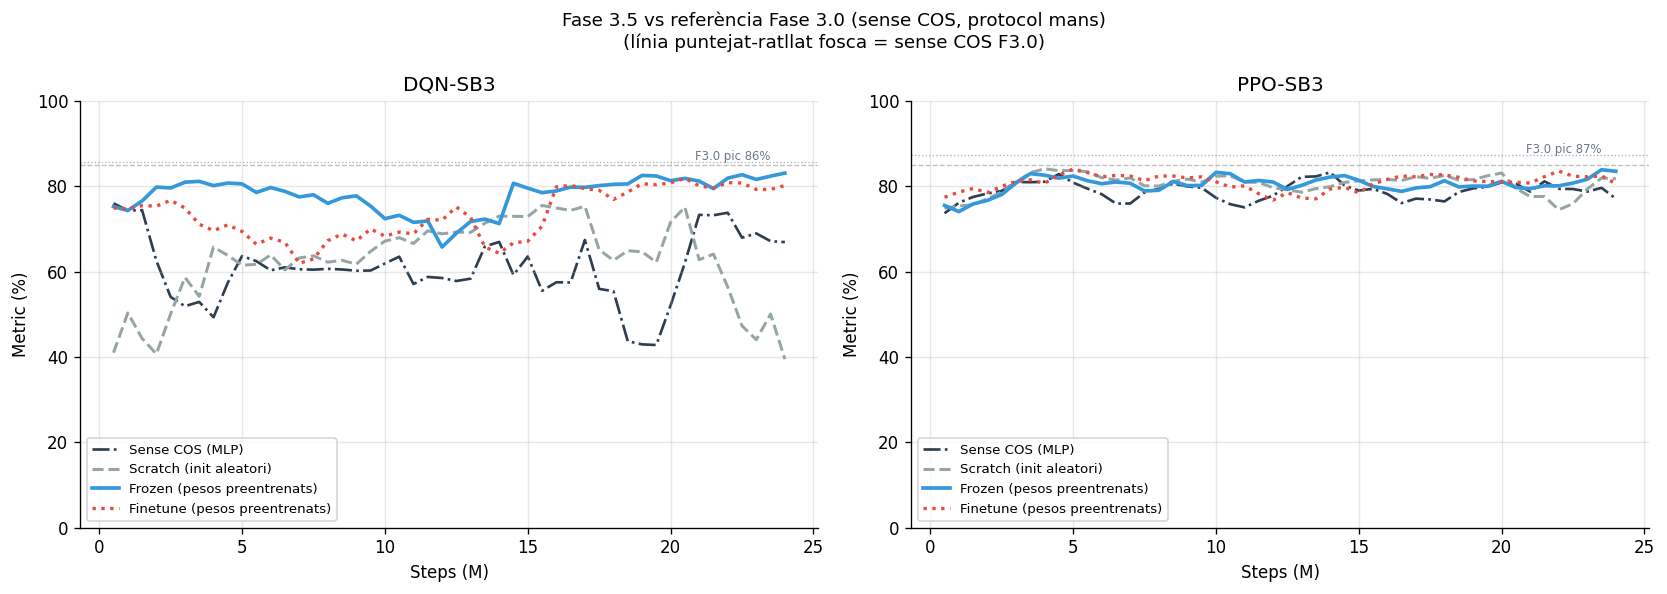

In [7]:
if dades and ref_sans_cos:
    WINDOW = 5
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Fase 3.5 vs referència Fase 3.0 (sense COS, protocol mans)\n'
                 '(línia puntejat-ratllat fosca = sense COS F3.0)', fontsize=11)

    for ax, agent in zip(axes, AGENTS):
        # Referència sense COS F3.0
        df_sans = ref_sans_cos.get(agent)
        if df_sans is not None:
            s_s = df_sans['step'] / 1e6
            ax.plot(s_s, suavitzar(df_sans['eval_metric'], WINDOW),
                    color=COLOR_SANS, linestyle=LSTYLE_SANS,
                    linewidth=LWIDTH_SANS, label=LABEL_SANS, zorder=1)
            pic_sans = df_sans['eval_metric'].max()
            ax.axhline(pic_sans, color=COLOR_SANS, linestyle=':', linewidth=0.8, alpha=0.4)
            ax.text(23.5, pic_sans + 0.5, f'F3.0 pic {pic_sans:.0f}%',
                    fontsize=7, color=COLOR_SANS, alpha=0.7, ha='right')

        for variant in VARIANTS:
            df = dades[agent].get(variant)
            if df is None:
                continue
            s = df['step'] / 1e6
            ax.plot(s, suavitzar(df['eval_metric'], WINDOW),
                    color=COLORS[variant], linestyle=LSTYLE[variant],
                    linewidth=LWIDTH[variant], label=LABELS_V[variant])

        ax.set_title(LABELS_A[agent], fontsize=12)
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel('Metric (%)')
        ax.set_ylim(0, 100)
        ax.axhline(85, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print('Falten dades de referència Fase 3.0 o Fase 3.5.')

---
## 8. Anàlisi per règim — sense COS vs scratch vs frozen vs finetune

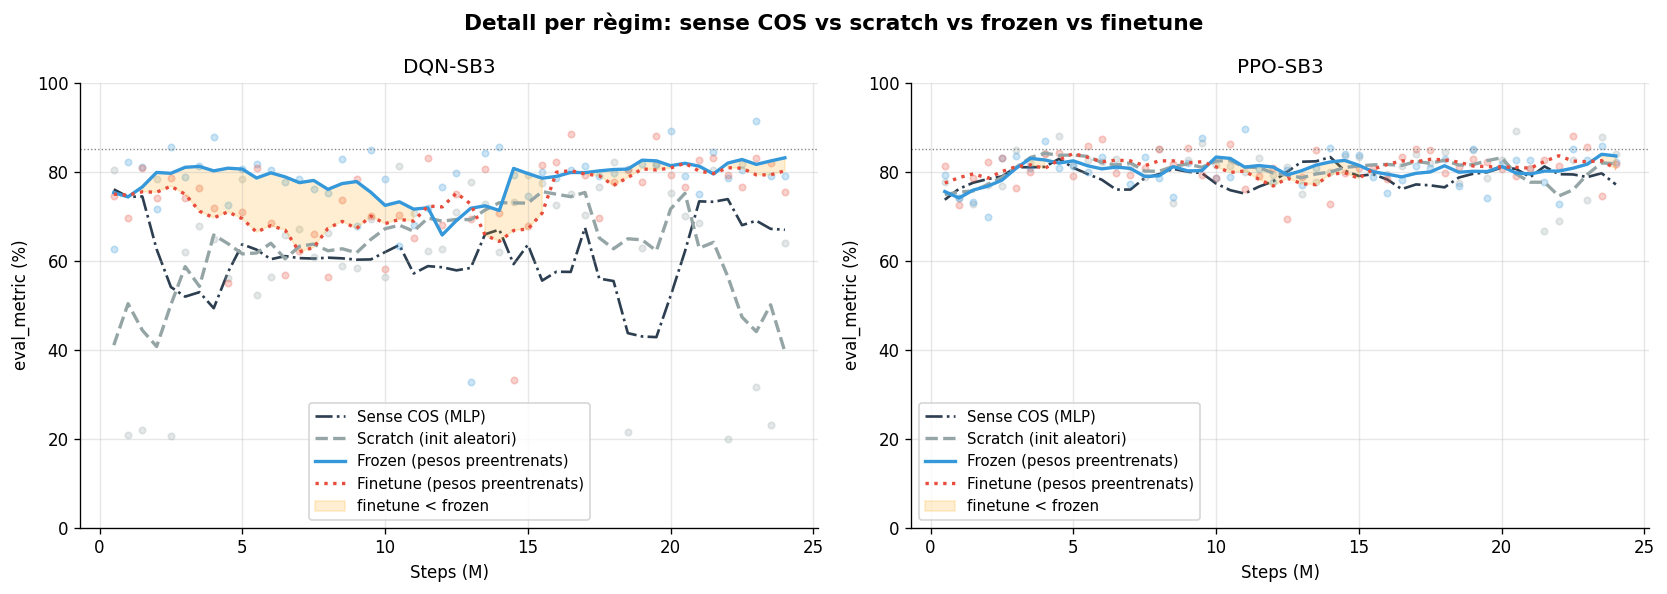

In [8]:
if dades:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Detall per règim: sense COS vs scratch vs frozen vs finetune', fontsize=13, fontweight='bold')

    for ax, agent in zip(axes, AGENTS):
        # Referència sense COS
        df_sans = ref_sans_cos.get(agent)
        if df_sans is not None:
            s = df_sans['step'] / 1e6
            ax.plot(s, suavitzar(df_sans['eval_metric']),
                    color=COLOR_SANS, linestyle=LSTYLE_SANS,
                    linewidth=LWIDTH_SANS, label=LABEL_SANS, zorder=1)

        for variant in VARIANTS:
            if agent not in dades or variant not in dades[agent]:
                continue
            df = dades[agent][variant]
            steps = df['step'] / 1e6
            metric_s = suavitzar(df['eval_metric'])
            ax.scatter(steps, df['eval_metric'], color=COLORS[variant], alpha=0.25, s=15)
            ax.plot(steps, metric_s, color=COLORS[variant],
                    linestyle=LSTYLE[variant], linewidth=2,
                    label=LABELS_V[variant])

        # Zona ombrejada: finetune < frozen (possible catastrophic forgetting)
        if agent in dades and 'frozen' in dades[agent] and 'finetune' in dades[agent]:
            df_fr = dades[agent]['frozen']
            df_ft = dades[agent]['finetune']
            steps_c = df_fr['step'] / 1e6
            fr_s = suavitzar(df_fr['eval_metric']).values
            ft_s = suavitzar(df_ft['eval_metric']).values
            min_len = min(len(steps_c), len(fr_s), len(ft_s))
            steps_c = steps_c.values[:min_len]
            fr_s = fr_s[:min_len]
            ft_s = ft_s[:min_len]
            mask = ft_s < fr_s
            if mask.any():
                ax.fill_between(steps_c, ft_s, fr_s,
                                where=mask, alpha=0.18, color='orange',
                                label='finetune < frozen')

        ax.set_title(LABELS_A[agent])
        ax.set_xlabel('Steps (M)')
        ax.set_ylabel('eval_metric (%)')
        ax.set_ylim(0, 100)
        ax.axhline(85, color='gray', linestyle=':', linewidth=0.8)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

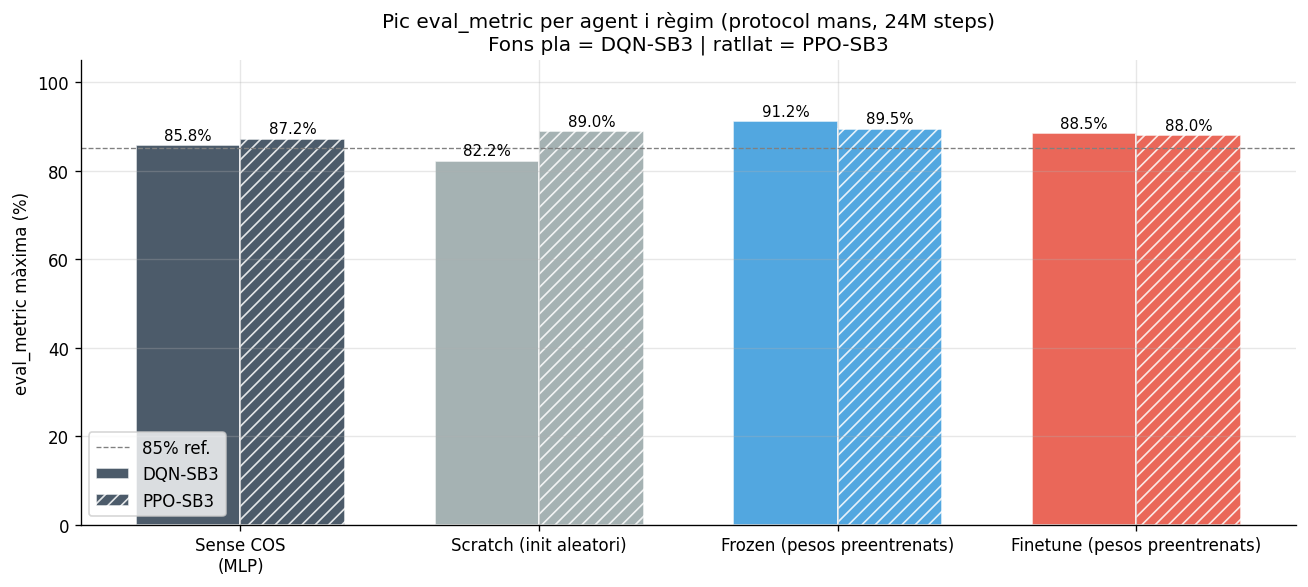


Valors numèrics:
  DQN-SB3 sense_cos: 85.8%
  DQN-SB3 scratch: 82.2%
  DQN-SB3 frozen: 91.2%
  DQN-SB3 finetune: 88.5%
  PPO-SB3 sense_cos: 87.2%
  PPO-SB3 scratch: 89.0%
  PPO-SB3 frozen: 89.5%
  PPO-SB3 finetune: 88.0%


In [9]:
if dades:
    pics = {}
    for agent in AGENTS:
        df = ref_sans_cos.get(agent)
        pics[(agent, 'sense_cos')] = df['eval_metric'].max() if df is not None else float('nan')
    for agent in AGENTS:
        for variant in VARIANTS:
            df = dades[agent].get(variant)
            pics[(agent, variant)] = df['eval_metric'].max() if df is not None else float('nan')

    all_regims = ['sense_cos'] + VARIANTS
    labels_regims = {
        'sense_cos': 'Sense COS\n(MLP)',
        'scratch':   LABELS_V['scratch'],
        'frozen':    LABELS_V['frozen'],
        'finetune':  LABELS_V['finetune'],
    }
    colors_bars = {
        'sense_cos': COLOR_SANS,
        'scratch':   COLORS['scratch'],
        'frozen':    COLORS['frozen'],
        'finetune':  COLORS['finetune'],
    }
    hatches = {'dqn_sb3': '', 'ppo_sb3': '///'}

    x = np.arange(len(all_regims))
    width = 0.35
    fig, ax = plt.subplots(figsize=(11, 5))

    for i, agent in enumerate(AGENTS):
        vals = [pics.get((agent, r), float('nan')) for r in all_regims]
        bars = ax.bar(x + i * width, vals, width,
                      label=LABELS_A[agent],
                      color=[colors_bars[r] for r in all_regims],
                      hatch=hatches[agent],
                      alpha=0.85, edgecolor='white')
        for bar, val in zip(bars, vals):
            if not np.isnan(val):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                        f'{val:.1f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x + width / 2)
    ax.set_xticklabels([labels_regims[r] for r in all_regims])
    ax.set_ylabel('eval_metric màxima (%)')
    ax.set_title('Pic eval_metric per agent i règim (protocol mans, 24M steps)\n'
                 'Fons pla = DQN-SB3 | ratllat = PPO-SB3')
    ax.set_ylim(0, 105)
    ax.axhline(85, color='gray', linestyle='--', linewidth=0.8, label='85% ref.')
    ax.legend()
    ax.grid(True, axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print('\nValors numèrics:')
    for agent in AGENTS:
        for r in all_regims:
            print(f'  {LABELS_A[agent]} {r}: {pics.get((agent, r), float("nan")):.1f}%')

---
## 9. Conclusions

### 9.1 Resum quantitatiu (protocol mans, 24M steps)

| Agent | Règim | Pic eval_metric |
|:--|:--|--:|
| DQN-SB3 | Sense COS (MLP) | 85.8% |
| DQN-SB3 | Scratch | 82.2% |
| DQN-SB3 | Frozen | **91.2%** |
| DQN-SB3 | Finetune | 88.5% |
| PPO-SB3 | Sense COS (MLP) | 87.2% |
| PPO-SB3 | Scratch | **89.0%** |
| PPO-SB3 | Frozen | 89.5% |
| PPO-SB3 | Finetune | 88.0% |

### 9.2 Valor del preentrenament

**Scratch vs sense COS**: la diferència és ≤3 pp per a ambdós agents (consistent amb Fase 3.0). L'arquitectura COS sola, sense preentrenament, no supera sistemàticament el MLP.

**Frozen vs sense COS**: frozen supera el MLP en ambdós casos (+5.4 pp DQN, +2.3 pp PPO). Confirma que és el **preentrenament**, no l'arquitectura sola, el que aporta valor real.

**Finetune vs sense COS**: finetune supera el MLP per a DQN (+2.7 pp) i marginalment per a PPO (+0.8 pp). El finetune és inferior al frozen en tots dos agents, cosa que suggereix que el gradient RL degrada parcialment la representació preentrenada (especialment per a DQN, on la diferència frozen-finetune és de 2.7 pp).

**Frozen vs scratch**: per a DQN el frozen és clarament millor (+9 pp). Per a PPO la diferència és molt petita (frozen +0.5 pp sobre scratch), confirmant que PPO no necessita el preentrenament.

### 9.3 Lectura per agent

**DQN-SB3**: molt sensible al règim d'inicialització. Frozen és el règim òptim (91.2%), superant el MLP en +5.4 pp i el scratch en +9 pp. Finetune queda per sota de frozen, indicant que el gradient RL no millora sinó que lleugerament degrada els pesos preentrenats. El cost computacional (~5h/run) és ~10× superior a PPO.

**PPO-SB3**: robust en tots els règims. Les quatre variants superen el 87% i es mantenen estables. El preentrenament no aporta millora significativa per a PPO: scratch (89.0%) és pràcticament equivalent a frozen (89.5%) i finetune (88.0%).


> **El preentrenament supervisat del COS aporta valor per a DQN via frozen** (+5.4 pp sobre MLP, +9 pp sobre scratch). Per a PPO l'efecte és negligible (≤2.3 pp). El règim òptim per agent és: **DQN → frozen**, **PPO → scratch** (més simple i equivalent en rendiment).

### 9.4 Conclusions finals

| Criteri | Recomanació |
|:--|:--|
| Millor rendiment absolut | DQN-SB3 + frozen (91.2%) |
| Millor relació rendiment/cost | PPO-SB3 + scratch (89.0%) |
| Millor estabilitat | PPO-SB3 (qualsevol règim) |